# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
A model is linear when it is linear in the coefficients. This means the prediction is made by adding together each variable multiplied by its coefficient. The variables themselves can be transformed but as long as the coefficients are multiplied and added, the model is still considered linear.
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
The coefficient of a dummy variable tells you how much the predicted outcome changes compared to the reference category. The intercept represents the prediction for the reference group. The dummy variable coefficient shows how much higher or lower the prediction is for that category compared to the reference group. 
3. Can linear regression be used for classification? Explain why, or why not.
Linear regression can technically be used for classification if the classes are coded as numbers (like 0 and 1). However, it's not ideal because linear regression predicts continuous values, which could be less than 0 or greater than 1. Classification models like logistic regression work better because they produce predictions that behave like probabilities.
4. What are signs that your linear model is over-fitting?
Overfitting happens when a model learns the training data too well but does not work well on new data. A common sign is very low error on the training data but much higher error on the test data. It can also happen when the model has too many features and starts fitting noise instead of the real pattern.
5. Clearly explain multi-colinearity using the two-stage least squares technique.
Multicollinearity happens when two or more predictor variables are very similar or strongly correlated. This makes it hard for the model to figure out how much each variable actually affects the outcome. In two-stage least squares, we first predict the problematic variable using other variables that are not strongly related to the error. Then we use this predicted version in the main regression. This helps separate the effects and gives more stable estimates.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
We can capture nonlinear relationships by transforming the variables. For example, we might include terms like x^2, x^3, or take the log of a variable. These added terms allow the model to represent curved or more complex relationships while still using linear regression.
7. What is the interpretation of the slope coefficient in a linear regression?
The slope coefficient tells us how much the predicted value of y changes when the predictor x increases by one unit, assuming the other variables in the model stay the same.
8. Compare the train/test split and $k$-fold cross validation.
A train/test split divides the data into two parts, one for training the model and one for testing how well it performs. The downside is that the results can depend a lot on how the data happened to be split.
In k-fold cross validation, the data is split into k parts. The model is trained multiple times, each time leaving out a different part for testing. The results are averaged, which usually gives a more reliable estimate of performance.
9. How is the $k$ in $k$-fold cross validation typically selected?
The value of k is usually chosen to balance accuracy and computation time. In practice, 5-fold or 10-fold cross validation is most common because it gives a good estimate of model performance without being too computationally expensive.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [6]:
df = pd.read_csv("./data/Q1_clean.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [7]:
print(df.columns)

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')


In [9]:
# rename variables
df = df.rename(columns={
    "Review Scores Rating": "ReviewScoresRating",
    "Neighbourhood ": "Neighbourhood"   # in case there is a trailing space
})

### 1. Average prices and scores by neighbourhood and kernel density plots

In [11]:
group_means = df.groupby("Neighbourhood")[["Price", "ReviewScoresRating"]].mean()
print(group_means.sort_values("Price", ascending=False))

most_expensive = group_means["Price"].idxmax()
print("Most expensive borough on average:", most_expensive)

                    Price  ReviewScoresRating
Neighbourhood                                
Manhattan      183.664286           91.801496
Staten Island  146.166667           90.843750
Brooklyn       127.747378           92.363497
Queens          96.857233           91.549057
Bronx           75.276498           91.654378
Most expensive borough on average: Manhattan


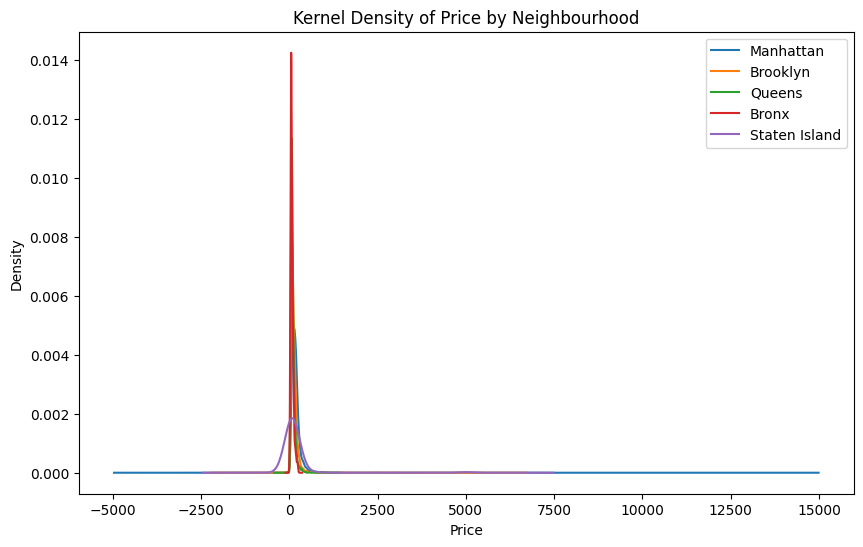

In [12]:
plt.figure(figsize=(10,6))
for n in df["Neighbourhood"].unique():
    df.loc[df["Neighbourhood"] == n, "Price"].plot(kind="kde", label=n)

plt.xlabel("Price")
plt.title("Kernel Density of Price by Neighbourhood")
plt.legend()
plt.show()

In [13]:
df = df[df["Price"] > 0].copy()
df["logPrice"] = np.log(df["Price"])

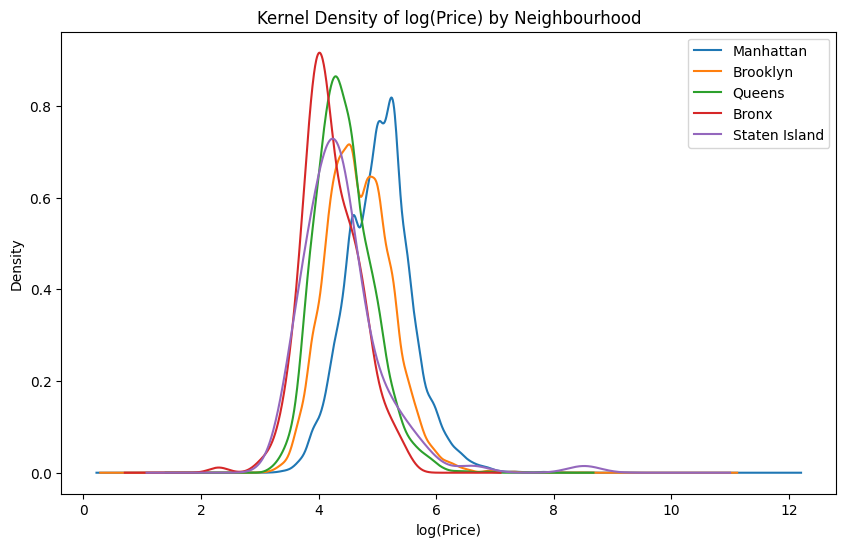

In [14]:
plt.figure(figsize=(10,6))
for n in df["Neighbourhood"].unique():
    df.loc[df["Neighbourhood"] == n, "logPrice"].plot(kind="kde", label=n)

plt.xlabel("log(Price)")
plt.title("Kernel Density of log(Price) by Neighbourhood")
plt.legend()
plt.show()

### 2. Regress Price on Neighbourhood using dummy variables

In [15]:
model_neigh = smf.ols("Price ~ C(Neighbourhood)", data=df).fit()
print(model_neigh.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sun, 15 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        13:17:59   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [16]:
print(model_neigh.params)

Intercept                             75.276498
C(Neighbourhood)[T.Brooklyn]          52.470881
C(Neighbourhood)[T.Manhattan]        108.387789
C(Neighbourhood)[T.Queens]            21.580735
C(Neighbourhood)[T.Staten Island]     70.890169
dtype: float64


In [17]:
print(df.groupby("Neighbourhood")["Price"].mean())

Neighbourhood
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64


I kept the intercept and dropped one category. The regression uses the Bronx as the reference category because it does not appear as a dummy variable. The intercept therefore represents the average price in the Bronx, which matches the group mean of $75.28. Each dummy coefficient represents the difference between that borough’s average price and the Bronx average. For example, the coefficient for Manhattan is about 108.39, meaning the average listing price in Manhattan is $108.39 higher than in the Bronx. Adding this coefficient to the intercept gives the Manhattan average price of about $183.66, which matches the group mean from Part 1. This shows that the regression coefficients are directly related to the conditional group means.

### 3. Regress Price on Review Scores Rating and interpret the slope

In [19]:
model_review = smf.ols("Price ~ ReviewScoresRating", data=df).fit()
print(model_review.summary())
print(model_review.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        13:26:33   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             60.8784     10

The estimated slope coefficient on ReviewScoresRating is approximately 1.02, meaning that the nightly price on average increases by about $1.02 for one point increase in the review score.

### 4. Regress Price on both Neighbourhood and Review Scores Rating

In [20]:
model_both = smf.ols("Price ~ ReviewScoresRating + C(Neighbourhood)", data=df).fit()
print(model_both.summary())
print(model_both.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Sun, 15 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        13:34:46   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

When neighborhood variables are added to the regression, the slope coefficient on ReviewScoresRating increases slightly from about 1.02 to 1.08. This means that a one-point increase in review score is associated with about a $1.08 increase in price when holding neighborhood constant. The neighborhood coefficients remain very similar to those from the previous regression using only neighborhood dummies, indicating that average price differences across boroughs do not change much after controlling for review scores. Additionally, the R^2 increases from 0.004 to 0.050, showing that neighborhood explains much more of the variation in price than review scores alone.

### 5. Separate slope coefficient for each neighborhood for Review Scores Rating

In [21]:
model_interaction = smf.ols("Price ~ C(Neighbourhood) * ReviewScoresRating", data=df).fit()
print(model_interaction.summary())
print(model_interaction.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:39:56   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

The baseline slope corresponds to the Bronx, where a one-point increase in review score is associated with about a $0.57 increase in price. The slopes for Brooklyn and Manhattan are larger (about $1.3 per rating point), while Queens is slightly smaller (about $0.5). Staten Island shows a large negative slope, which is likely due to a small number of observations or outliers. Overall, the slopes are fairly similar across most neighborhoods, suggesting that the relationship between review scores and price does not vary dramatically across boroughs, except for Staten Island.

### 6. Use cross validation to evaluate the models

In [22]:
# Model A
X1 = df[["ReviewScoresRating"]]
y = df["Price"]

cv = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()

scores1 = cross_val_score(lr, X1, y, cv=cv, scoring="r2")
rmse1 = -cross_val_score(lr, X1, y, cv=cv, scoring="neg_root_mean_squared_error")

print("Model A: Review score only")
print("Mean CV R^2:", scores1.mean())
print("Mean CV RMSE:", rmse1.mean())

Model A: Review score only
Mean CV R^2: 0.004101046884493842
Mean CV RMSE: 144.1736262473453


In [23]:
# Model B
X2 = df[["ReviewScoresRating", "Neighbourhood"]]

preprocessor2 = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), ["Neighbourhood"]),
    ("num", "passthrough", ["ReviewScoresRating"])
])

model2 = Pipeline([
    ("prep", preprocessor2),
    ("reg", LinearRegression())
])

scores2 = cross_val_score(model2, X2, y, cv=cv, scoring="r2")
rmse2 = -cross_val_score(model2, X2, y, cv=cv, scoring="neg_root_mean_squared_error")

print("Model B: Review score + neighborhood")
print("Mean CV R^2:", scores2.mean())
print("Mean CV RMSE:", rmse2.mean())

Model B: Review score + neighborhood
Mean CV R^2: 0.05764902590310024
Mean CV RMSE: 140.51652264524594


In [24]:
# Model C
X3 = pd.get_dummies(df[["Neighbourhood"]], drop_first=True)
X3["ReviewScoresRating"] = df["ReviewScoresRating"]

for col in X3.columns:
    if col != "ReviewScoresRating":
        X3[f"{col}_x_Review"] = X3[col] * df["ReviewScoresRating"]

scores3 = cross_val_score(lr, X3, y, cv=cv, scoring="r2")
rmse3 = -cross_val_score(lr, X3, y, cv=cv, scoring="neg_root_mean_squared_error")

print("Model C: neighborhood + review score + interactions")
print("Mean CV R^2:", scores3.mean())
print("Mean CV RMSE:", rmse3.mean())

Model C: neighborhood + review score + interactions
Mean CV R^2: 0.04107735011286786
Mean CV RMSE: 141.56707344661336


In [25]:
# comparison
cv_results = pd.DataFrame({
    "Model": [
        "Review score only",
        "Review score + neighborhood",
        "Review score + neighborhood interactions"
    ],
    "Mean CV R2": [
        scores1.mean(),
        scores2.mean(),
        scores3.mean()
    ],
    "Mean CV RMSE": [
        rmse1.mean(),
        rmse2.mean(),
        rmse3.mean()
    ]
})

print(cv_results)

                                      Model  Mean CV R2  Mean CV RMSE
0                         Review score only    0.004101    144.173626
1               Review score + neighborhood    0.057649    140.516523
2  Review score + neighborhood interactions    0.041077    141.567073


Using 5-fold cross validation, the model including both review score and neighborhood performs best, with the highest cross-validated R^2 (0.0576) and the lowest RMSE (140.52). The model using review score alone performs poorly, explaining almost none of the variation in price. Adding interaction terms between review score and neighborhood slightly worsens predictive performance, likely because the additional parameters increase model complexity without providing meaningful improvements in prediction. Overall, neighborhood appears to be much more important than review scores for predicting listing prices.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

In [27]:
df = pd.read_csv("./data/cars_hw.csv")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [28]:
print(df.columns)
df.info()

Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         976 non-null    int64 
 1   Make               976 non-null    object
 2   Make_Year          976 non-null    int64 
 3   Color              976 non-null    object
 4   Body_Type          976 non-null    object
 5   Mileage_Run        976 non-null    int64 
 6   No_of_Owners       976 non-null    object
 7   Seating_Capacity   976 non-null    int64 
 8   Fuel_Type          976 non-null    object
 9   Transmission       976 non-null    object
 10  Transmission_Type  976 non-null    object
 11  Price              976 non-null    int64 
dtypes: int64(5), object(7

### 1. Summarize Price and make KDE plots

In [29]:
print(df["Price"].describe())

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


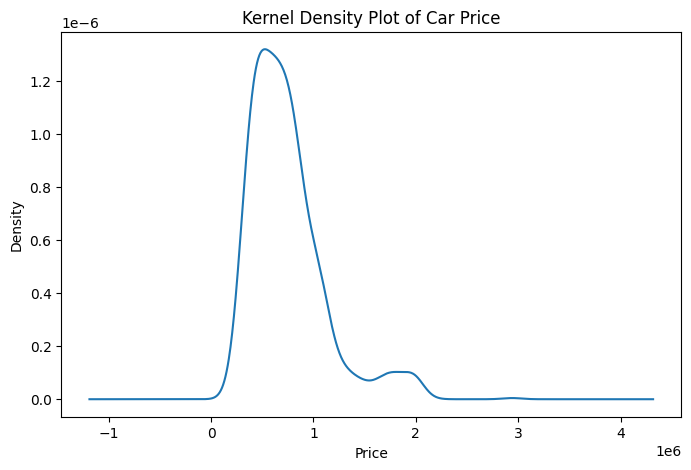

In [30]:
plt.figure(figsize=(8,5))
df["Price"].plot(kind="kde")
plt.xlabel("Price")
plt.title("Kernel Density Plot of Car Price")
plt.show()

In [31]:
price_by_body = df.groupby("Body_Type")["Price"].describe()
print(price_by_body)

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


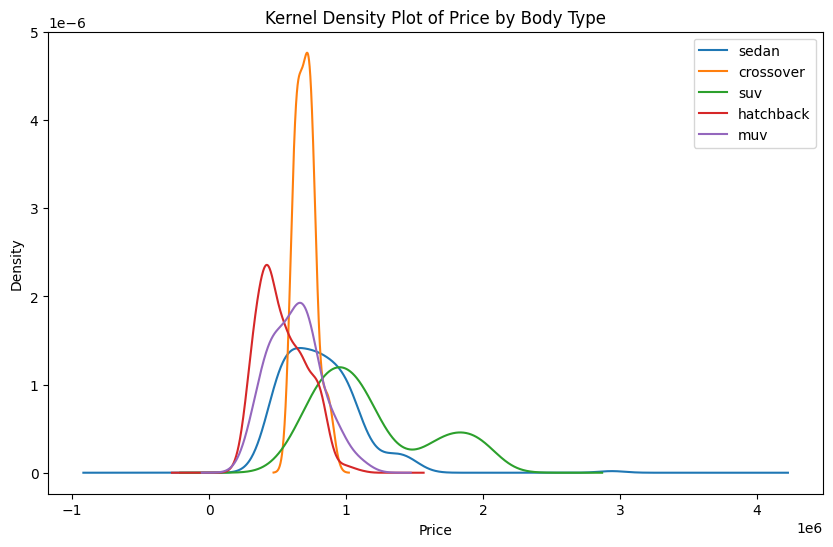

In [32]:
plt.figure(figsize=(10,6))

for b in df["Body_Type"].unique():
    df.loc[df["Body_Type"] == b, "Price"].plot(kind="kde", label=b)

plt.xlabel("Price")
plt.title("Kernel Density Plot of Price by Body Type")
plt.legend()
plt.show()

The most expensive car type is the crossover followed by hatchback and muv. SUV and sedans have the highest variance.  

### 2. Regress Price on Seating_Capacity

In [33]:
model_seats_linear = smf.ols("Price ~ Seating_Capacity", data=df).fit()
print(model_seats_linear.summary())
print(model_seats_linear.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Sun, 15 Mar 2026   Prob (F-statistic):             0.0245
Time:                        14:12:37   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

The slope is about 59268, meaning the average increase of car price is $59268 for a one-seat increase in seating capacity. 

In [34]:
model_seats_cat = smf.ols("Price ~ C(Seating_Capacity)", data=df).fit()
print(model_seats_cat.summary())
print(model_seats_cat.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           0.000267
Time:                        14:15:22   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [35]:
print(df.groupby("Seating_Capacity")["Price"].mean())

Seating_Capacity
4    1.880000e+05
5    7.344839e+05
6    1.644000e+06
7    9.239487e+05
8    4.598000e+05
Name: Price, dtype: float64


Comparing the average prices across seat counts shows that the relationship is not linear, prices increase sharply from 4 to 6 seats but then decrease for 7 and 8 seats. This suggests that seating capacity alone does not have a simple linear relationship with price and may reflect different types of vehicles.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
